# Solution: Seaborn — Swiss EV Charging Stations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/ev_charging_stations.csv')
print('Shape:', df.shape)

Shape: (2442, 15)


### Task 1 — `histplot` with KDE, coloured by `power_type`

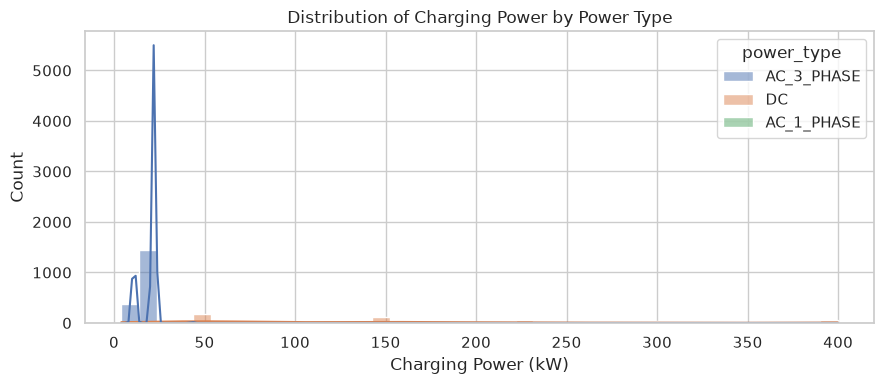

In [2]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='power_kw', hue='power_type', kde=True, bins=40, alpha=0.5, ax=ax)
ax.set_xlabel('Charging Power (kW)')
ax.set_title('Distribution of Charging Power by Power Type')
plt.tight_layout()
plt.show()

### Task 2 — `boxplot`: `power_kw` by `power_type`

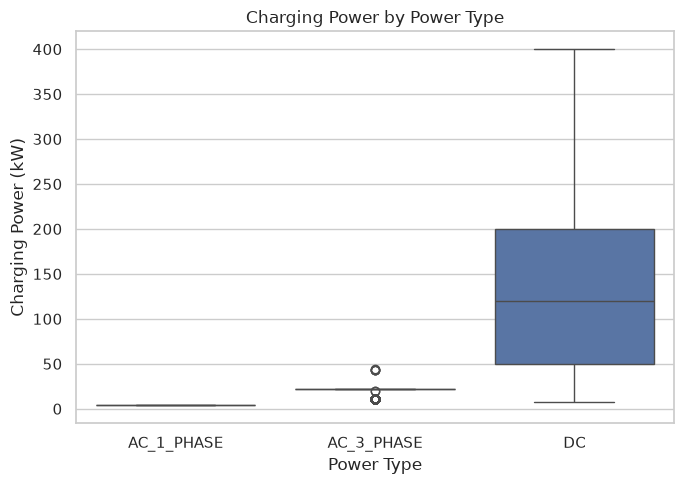

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='power_type', y='power_kw',
            order=['AC_1_PHASE', 'AC_3_PHASE', 'DC'], ax=ax)
ax.set_xlabel('Power Type')
ax.set_ylabel('Charging Power (kW)')
ax.set_title('Charging Power by Power Type')
plt.tight_layout()
plt.show()

### Task 3 — `violinplot`: `power_kw` by `power_type`

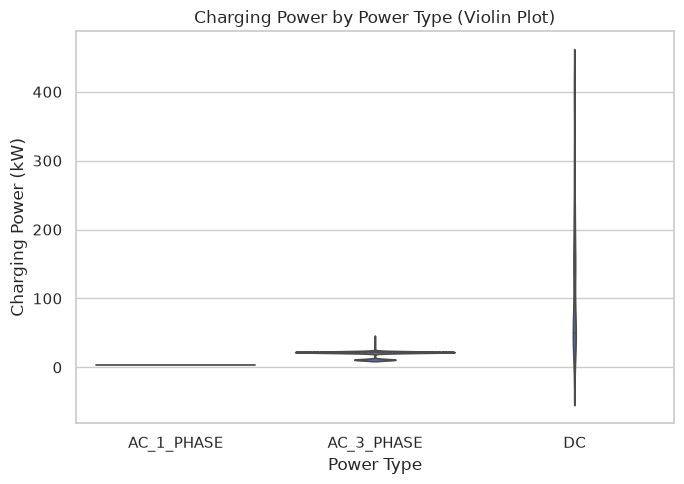

Interpretation:
The violin plot shows the full shape of the distribution (not just quartiles).
For DC: the wide body at higher kW values reveals a multi-modal distribution
(clusters at 50 kW, 150 kW and 350+ kW), which the box plot hides.
For AC_3_PHASE: the very narrow violin confirms that nearly all stations are at 22 kW.


In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=df, x='power_type', y='power_kw',
               order=['AC_1_PHASE', 'AC_3_PHASE', 'DC'],
               inner='quartile', ax=ax)
ax.set_xlabel('Power Type')
ax.set_ylabel('Charging Power (kW)')
ax.set_title('Charging Power by Power Type (Violin Plot)')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('The violin plot shows the full shape of the distribution (not just quartiles).')
print('For DC: the wide body at higher kW values reveals a multi-modal distribution')
print('(clusters at 50 kW, 150 kW and 350+ kW), which the box plot hides.')
print('For AC_3_PHASE: the very narrow violin confirms that nearly all stations are at 22 kW.')

### Task 4 — `countplot`: count per `plug_type`

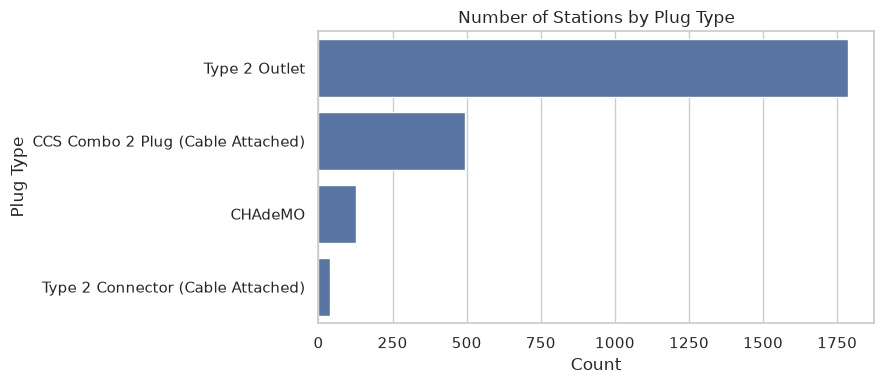

In [5]:
order = df['plug_type'].value_counts().index

fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(data=df, y='plug_type', order=order, ax=ax)
ax.set_xlabel('Count')
ax.set_ylabel('Plug Type')
ax.set_title('Number of Stations by Plug Type')
plt.tight_layout()
plt.show()

### Task 5 — `scatterplot`: `voltage` vs. `amperage`

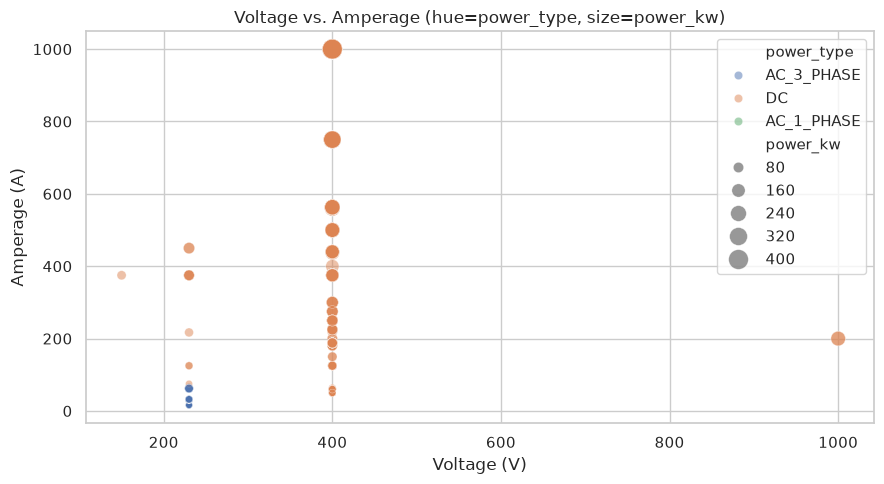

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x='voltage', y='amperage',
                hue='power_type', size='power_kw',
                sizes=(20, 200), alpha=0.5, ax=ax)
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Amperage (A)')
ax.set_title('Voltage vs. Amperage (hue=power_type, size=power_kw)')
plt.tight_layout()
plt.show()

### Task 6 — `pairplot`

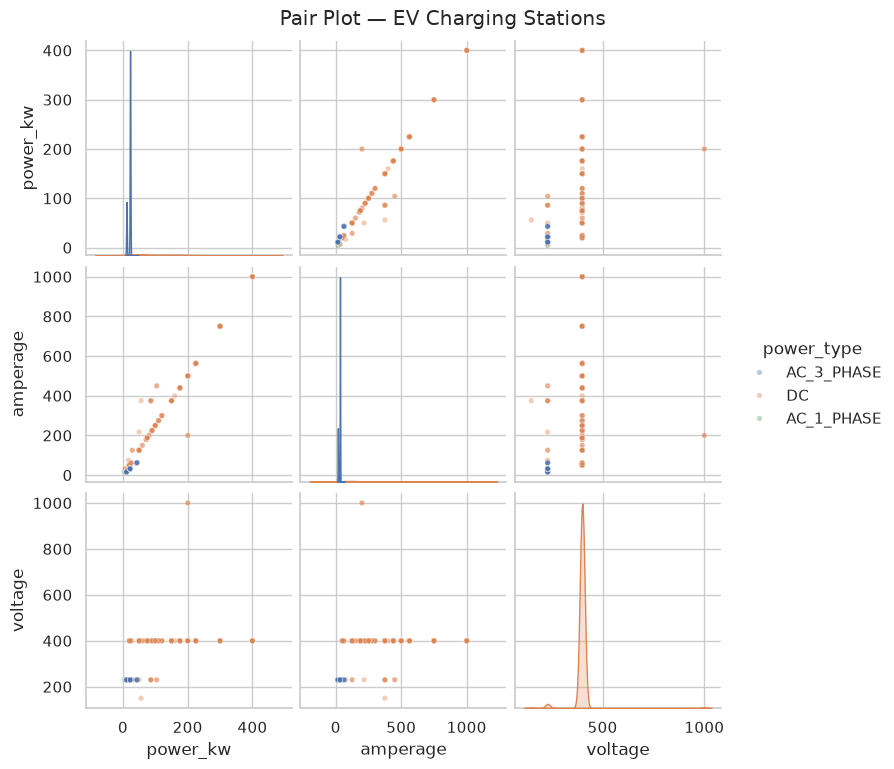

In [7]:
num_cols = ['power_kw', 'amperage', 'voltage']
g = sns.pairplot(
    df[num_cols + ['power_type']],
    hue='power_type',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15}
)
g.fig.suptitle('Pair Plot — EV Charging Stations', y=1.02)
plt.show()

### Task 7 — `heatmap`: Pearson correlation matrix

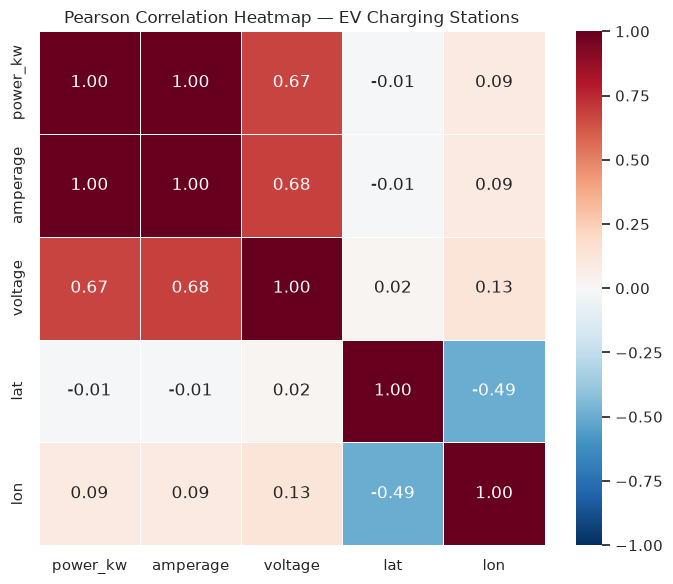

In [8]:
num_cols = ['power_kw', 'amperage', 'voltage', 'lat', 'lon']
corr = df[num_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Heatmap — EV Charging Stations')
plt.tight_layout()
plt.show()

## Jupyter notebook --footer info--
(please always provide this at the end of each notebook)

In [9]:
import os, platform, socket
from platform import python_version
from datetime import datetime
print('------------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print('Python Version:', python_version())
print('------------------------------------')

------------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-10-01 08:11:22
Python Version: 3.11.16
------------------------------------
